In [ ]:
!pip install wordcloud seaborn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud

In [ ]:
np.random.seed(42)

n = 300

data = {
    "Respondent_ID": range(1, n+1),
    "Age_Group": np.random.choice(["18-24", "25-34", "35-44"], n),
    "Gender": np.random.choice(["Male", "Female"], n),
    "Region": np.random.choice(["East", "West", "North", "South"], n),
    "Preferred_Tool": np.random.choice(["Python", "R", "Excel", "Power BI"], n),
    "Satisfaction": np.random.randint(1, 6, n),
    "Feedback": np.random.choice([
        "Great tool", "Very useful", "Needs improvement",
        "Excellent", "Not bad", "Could be better"
    ], n),
    "Date": pd.date_range(start="2024-01-01", periods=n, freq='D')
}

df = pd.DataFrame(data)

df.head()

,Respondent_ID,Age_Group,Gender,Region,Preferred_Tool,Satisfaction,Feedback,Date
0,1,35-44,Male,East,R,5,Not bad,2024-01-01
1,2,18-24,Female,East,Power BI,1,Could be better,2024-01-02
2,3,35-44,Male,East,R,1,Could be better,2024-01-03
3,4,35-44,Male,North,R,5,Great tool,2024-01-04
4,5,18-24,Female,North,Excel,5,Very useful,2024-01-05


In [ ]:
df.to_csv("poll_data.csv", index=False)

In [ ]:
# Remove duplicates
df = df.drop_duplicates()

# Handle missing values
df = df.dropna()

# Standardize text
df["Preferred_Tool"] = df["Preferred_Tool"].str.strip().str.title()

# Convert types
df["Satisfaction"] = pd.to_numeric(df["Satisfaction"])

df.head()

,Respondent_ID,Age_Group,Gender,Region,Preferred_Tool,Satisfaction,Feedback,Date
0,1,35-44,Male,East,R,5,Not bad,2024-01-01
1,2,18-24,Female,East,Power Bi,1,Could be better,2024-01-02
2,3,35-44,Male,East,R,1,Could be better,2024-01-03
3,4,35-44,Male,North,R,5,Great tool,2024-01-04
4,5,18-24,Female,North,Excel,5,Very useful,2024-01-05


In [ ]:
tool_counts = df["Preferred_Tool"].value_counts()
tool_percent = (tool_counts / len(df)) * 100

print("Vote Count:\n", tool_counts)
print("\nVote Percentage:\n", tool_percent)

Vote Count:
 Preferred_Tool
R           83
Python      81
Excel       79
Power Bi    57
Name: count, dtype: int64

Vote Percentage:
 Preferred_Tool
R           27.666667
Python      27.000000
Excel       26.333333
Power Bi    19.000000
Name: count, dtype: float64


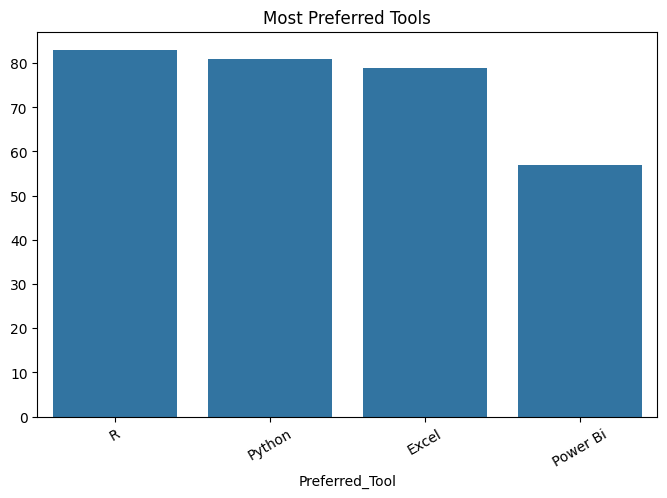

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(x=tool_counts.index, y=tool_counts.values)
plt.title("Most Preferred Tools")
plt.xticks(rotation=30)
plt.show()

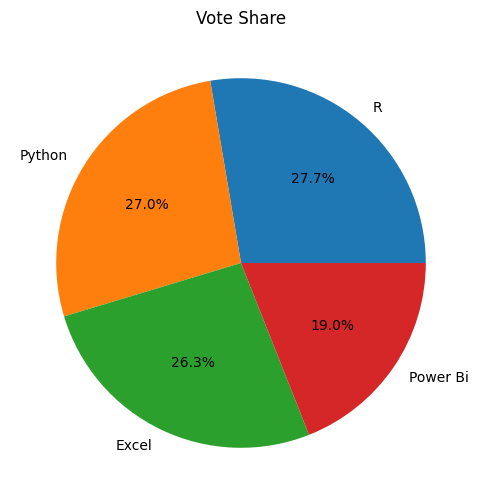

In [ ]:
plt.figure(figsize=(6,6))
plt.pie(tool_counts, labels=tool_counts.index, autopct="%1.1f%%")
plt.title("Vote Share")
plt.show()

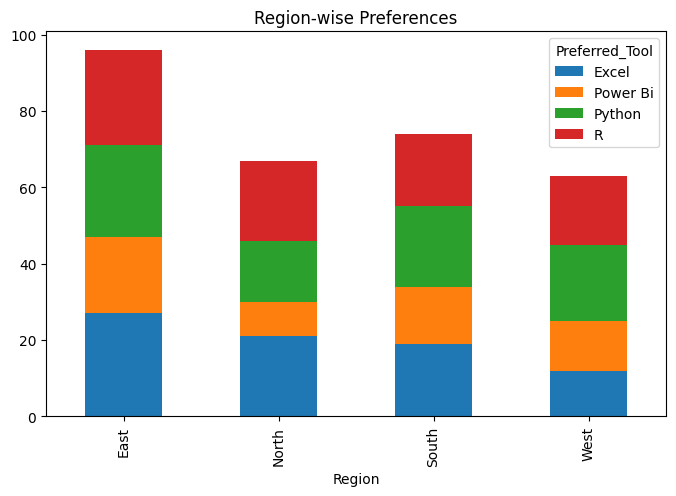

In [ ]:
region_tool = pd.crosstab(df["Region"], df["Preferred_Tool"])

region_tool.plot(kind="bar", stacked=True, figsize=(8,5))
plt.title("Region-wise Preferences")
plt.show()

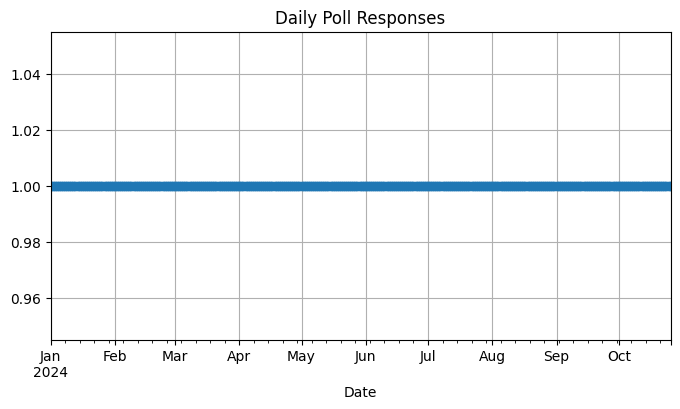

In [ ]:
daily = df.groupby("Date").size()

plt.figure(figsize=(8,4))
daily.plot(marker='o')
plt.title("Daily Poll Responses")
plt.grid(True)
plt.show()

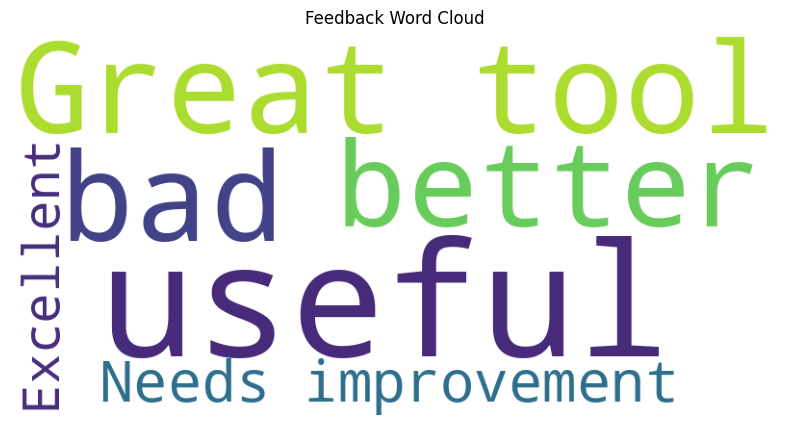

In [ ]:
text = " ".join(df["Feedback"].astype(str))

wordcloud = WordCloud(width=800, height=400, background_color="white").generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Feedback Word Cloud")
plt.show()

In [ ]:
top_tool = tool_counts.idxmax()

print("Top Tool:", top_tool)
print("Insight: Most users prefer", top_tool)

avg_satisfaction = df["Satisfaction"].mean()
print("Average Satisfaction:", round(avg_satisfaction, 2))

Top Tool: R
Insight: Most users prefer R
Average Satisfaction: 3.01


In [ ]:
responses = []

n = int(input("Enter number of responses: "))

for i in range(n):
    print(f"\nResponse {i+1}")

    age = input("Age Group (18-24 / 25-34 / 35-44): ")
    region = input("Region (East/West/North/South): ")
    tool = input("Preferred Tool (Python/R/Excel/Power BI): ")
    satisfaction = int(input("Satisfaction (1-5): "))
    feedback = input("Feedback: ")

    responses.append([age, region, tool, satisfaction, feedback])

df = pd.DataFrame(responses, columns=[
    "Age_Group", "Region", "Preferred_Tool", "Satisfaction", "Feedback"
])

df.head()

Enter number of responses: 5

Response 1
Age Group (18-24 / 25-34 / 35-44): 18-24
Region (East/West/North/South): east
Preferred Tool (Python/R/Excel/Power BI): power bi
Satisfaction (1-5): 5
Feedback: good

Response 2
Age Group (18-24 / 25-34 / 35-44): 25-34
Region (East/West/North/South): north
Preferred Tool (Python/R/Excel/Power BI): python
Satisfaction (1-5): 4
Feedback: nice

Response 3
Age Group (18-24 / 25-34 / 35-44): 35-44
Region (East/West/North/South): west
Preferred Tool (Python/R/Excel/Power BI): r
Satisfaction (1-5): 2
Feedback: poor

Response 4
Age Group (18-24 / 25-34 / 35-44): 25+34
Region (East/West/North/South): north
Preferred Tool (Python/R/Excel/Power BI): excel
Satisfaction (1-5): 3
Feedback: good

Response 5
Age Group (18-24 / 25-34 / 35-44): 25-34
Region (East/West/North/South): south
Preferred Tool (Python/R/Excel/Power BI): excel
Satisfaction (1-5): 4
Feedback: good


,Age_Group,Region,Preferred_Tool,Satisfaction,Feedback
0,18-24,east,power bi,5,good
1,25-34,north,python,4,nice
2,35-44,west,r,2,poor
3,25+34,north,excel,3,good
4,25-34,south,excel,4,good
